#Import modules

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

#Data

In [3]:
rna = pd.read_csv('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/transfer_model_rna_met.csv', index_col = 0)
rna = rna.drop('ENSG00000211592', axis = 'columns')
rna

,ENSG00000198712,ENSG00000198804,ENSG00000198938,ENSG00000198899,ENSG00000198886,ENSG00000212907,ENSG00000198763,ENSG00000198840,ENSG00000156508,ENSG00000198888,...,ENSG00000205923,ENSG00000183747,ENSG00000066813,ENSG00000182601,ENSG00000156885,ENSG00000182156,ENSG00000166948,ENSG00000197838,ENSG00000167751,ENSG00000182415
MSKC-00397,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2929.049654,0.000000,...,19.356151,5.898651,8.225321,0.026444,0.384994,2.161147,0.0,0.0,0.127099,0.0
MSKC-00399,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3537.456407,0.000000,...,23.797005,173.680890,235.708998,0.000000,4.840216,4.216679,0.0,0.0,0.000000,0.0
MSKC-00400,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2044.849531,0.000000,...,23.372477,534.686682,411.479407,0.000000,0.000000,0.316985,0.0,0.0,0.000000,0.0
MSKC-00404,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1924.739209,0.000000,...,12.879372,2.846888,2.450864,0.000000,0.181166,0.043275,0.0,0.0,0.119617,0.0
MSKC-00405,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3383.095180,0.000000,...,13.380325,42.575867,43.357611,0.000000,0.712212,0.623798,0.0,0.0,0.031350,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
PT-P44H,8571.429287,17179.401555,23464.738546,2342.497720,2077.589370,1672.320980,991.709725,4296.102685,639.119482,1805.448697,...,0.000000,0.007620,0.000000,0.284963,0.263497,0.016270,0.0,0.0,0.004840,0.0
PT-R55F,18201.188720,41993.614826,33487.607762,5915.373624,6624.868872,4407.879407,2198.822304,5340.948488,543.069734,3933.385374,...,0.000000,0.006537,0.008831,0.192258,0.508649,0.010469,0.0,0.0,0.000000,0.0
PT-RN5K,24914.753870,42438.590948,43327.418655,7302.553299,5565.766122,4548.764104,2456.168366,14379.607123,425.398947,4166.642804,...,0.000000,0.005306,0.000000,0.375665,0.688057,0.059481,0.0,0.0,0.015166,0.0
PT-UTHO,9807.911905,24295.357770,15931.321343,2560.097360,3230.971666,2188.588214,1389.769218,1850.104503,645.661990,2215.177211,...,0.000000,0.000000,0.000000,0.399252,0.000000,0.117592,0.0,0.0,0.000000,0.0


In [4]:
metabolites = pd.read_csv('drive/My Drive/Colab Notebooks/Metabolite_prediction_ML/metabolomics_log2.csv', index_col = 0)
metabolites = metabolites.T
metabolites

,"1,2-propanediol","1,5-anhydroglucitol (1,5-AG)",1-arachidonoyl-GPC (20:4n6),1-arachidonoyl-GPE (20:4n6),1-arachidonoyl-GPI (20:4),1-eicosatrienoylglycerophosphocholine (20:3),1-margaroylglycerophosphocholine (17:0),1-linoleoylglycerol (18:2),1-linoleoyl-GPC (18:2),1-linoleoylglycerophosphoethanolamine,...,malonate,metronidazole,N-carboxymethylalanine,N1-Methyl-4-pyridone-3-carboxamide,N6-methyladenosine,nicotinate ribonucleoside,norfluoxetine,palmitoleoyl ethanolamide,succinimide,thyroxine
DUKE-00651,21.037723,19.394321,17.671134,14.233610,14.384728,16.818972,15.262543,14.061858,18.733537,13.836203,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DUKE-00652,23.959087,19.044231,14.631118,16.423374,16.305192,13.493080,13.337998,16.244013,14.342457,14.410637,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DUKE-00653,20.682481,19.193116,15.608743,14.400485,15.299840,14.887658,14.486196,15.090475,16.891647,14.514168,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DUKE-00654,19.963768,19.653941,15.383235,15.369813,14.913759,14.578475,13.337998,14.576805,17.531595,16.108259,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DUKE-00657,19.677653,20.145794,17.854153,14.785590,14.445883,16.213699,13.337998,14.759995,19.931038,15.195652,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
MSKC-00483,NaN,20.623605,20.772511,22.201466,23.203913,NaN,NaN,23.400548,21.974739,NaN,...,20.905649,19.987368,13.949308,18.857947,18.121721,15.876410,21.917796,14.204030,16.028156,13.218192
MSKC-00484,NaN,19.709740,21.012143,21.916148,21.409801,NaN,NaN,22.066585,23.908872,NaN,...,19.997085,19.987368,18.341589,15.813626,18.832340,15.876410,21.917796,14.081109,15.167041,13.218192
MSKC-00485,NaN,19.393769,20.316594,20.322285,20.074359,NaN,NaN,19.395849,21.530004,NaN,...,20.422488,19.987368,17.367652,19.865964,16.375009,18.547371,21.917796,13.940225,16.306077,13.218192
MSKC-00486,NaN,18.795282,19.099814,21.605296,22.077745,NaN,NaN,21.328106,20.474841,NaN,...,20.117567,19.987368,17.310323,19.386511,16.781328,15.876410,21.917796,13.940225,20.522298,13.218192


In [5]:
threshold = 0.2
nan_percentage = metabolites.isnull().mean()
filtered_metabolites = metabolites.loc[:, nan_percentage <= threshold]
metabolites = filtered_metabolites
metabolites

,"1,5-anhydroglucitol (1,5-AG)",1-arachidonoyl-GPC (20:4n6),1-arachidonoyl-GPE (20:4n6),1-arachidonoyl-GPI (20:4),1-linoleoylglycerol (18:2),1-linoleoyl-GPC (18:2),1-oleoylglycerol (1-monoolein),1-oleoyl-GPE (18:1),1-palmitoleoyl-GPC (16:1),1-palmitoylglycerol (1-monopalmitin),...,urea,uridine,valine,valylglycine,xanthine,xanthosine,3-phosphoglycerate,dehydroascorbate,pyruvate,phosphoenolpyruvate (PEP)
DUKE-00651,19.394321,17.671134,14.233610,14.384728,14.061858,18.733537,14.160222,17.035593,18.238785,16.193003,...,19.791208,17.280007,20.914748,13.103914,15.290542,11.141052,NaN,NaN,NaN,NaN
DUKE-00652,19.044231,14.631118,16.423374,16.305192,16.244013,14.342457,14.630229,17.097542,14.162099,16.343955,...,20.714696,17.931028,20.966490,11.180255,14.081160,15.169395,NaN,NaN,NaN,NaN
DUKE-00653,19.193116,15.608743,14.400485,15.299840,15.090475,16.891647,14.793942,16.787389,15.598227,16.307270,...,20.026746,17.416825,20.626487,12.483334,13.719496,10.940461,NaN,NaN,NaN,NaN
DUKE-00654,19.653941,15.383235,15.369813,14.913759,14.576805,17.531595,13.698657,17.498170,15.382139,14.735908,...,19.417532,17.333397,20.786484,12.785167,15.008995,11.457243,NaN,NaN,NaN,NaN
DUKE-00657,20.145794,17.854153,14.785590,14.445883,14.759995,19.931038,14.140832,16.189295,16.830153,13.092027,...,20.029593,18.298603,20.829264,12.072888,12.760453,10.473938,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
MSKC-00483,20.623605,20.772511,22.201466,23.203913,23.400548,21.974739,23.832628,21.126642,15.528993,23.714071,...,23.642103,22.356899,26.906058,13.804900,20.249497,18.873510,21.795535,21.284580,19.835953,20.788527
MSKC-00484,19.709740,21.012143,21.916148,21.409801,22.066585,23.908872,22.744470,24.818447,19.777455,22.367748,...,23.335062,18.983131,28.243038,16.627670,19.755282,19.011004,22.483612,22.112696,17.565157,21.367133
MSKC-00485,19.393769,20.316594,20.322285,20.074359,19.395849,21.530004,21.115255,21.695953,17.689438,22.340078,...,24.068418,21.271504,28.150188,13.804900,21.861710,20.761065,20.709723,22.940596,19.620601,19.702365
MSKC-00486,18.795282,19.099814,21.605296,22.077745,21.328106,20.474841,22.967082,21.579612,16.366178,22.815021,...,24.338312,22.174396,28.327350,15.008651,21.947564,18.447479,20.908825,21.293467,17.466552,20.561626


#Log2 transformation

In [6]:
rna = rna.apply(lambda x: np.log2(x + 1))
rna.head(3)

,ENSG00000198712,ENSG00000198804,ENSG00000198938,ENSG00000198899,ENSG00000198886,ENSG00000212907,ENSG00000198763,ENSG00000198840,ENSG00000156508,ENSG00000198888,...,ENSG00000205923,ENSG00000183747,ENSG00000066813,ENSG00000182601,ENSG00000156885,ENSG00000182156,ENSG00000166948,ENSG00000197838,ENSG00000167751,ENSG00000182415
MSKC-00397,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,11.516709,0.0,...,4.347393,2.786314,3.205599,0.037654,0.469879,1.660448,0.0,0.0,0.172614,0.0
MSKC-00399,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,11.788904,0.0,...,4.632094,7.448578,7.886971,0.000000,2.546022,2.383132,0.0,0.0,0.000000,0.0
MSKC-00400,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10.998484,0.0,...,4.607181,9.065246,8.688178,0.000000,0.000000,0.397239,0.0,0.0,0.000000,0.0


#Data shuffling

In [7]:
combined_data = pd.concat([rna, metabolites], axis=1)
shuffled_data = combined_data.sample(frac=1, random_state=0)
shuffled_rna = shuffled_data[rna.columns]
shuffled_metabolites = shuffled_data[metabolites.columns]

rna = shuffled_rna
metabolites = shuffled_metabolites

#Data imputation and normalization [-1, 1]

In [8]:
from sklearn.impute import SimpleImputer

def impute_normalize(df):
  data = df.copy()
  imputer = SimpleImputer(strategy='median')
  data = imputer.fit_transform(data)
  min_val = np.min(data)
  max_val = np.max(data)
  data_scaled = 2 * ((data - min_val) / (max_val - min_val)) - 1
  data_scaled = data_scaled.astype(np.float32)
  print('min:', np.min(data_scaled))
  print('max:', np.max(data_scaled))
  print('shape:', data_scaled.shape)

  return data_scaled

#Neural network

In [9]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [10]:
import pickle

with open('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/models/ENSG00000211592_metabolic_genes_nn_model_input_features.pkl', 'rb') as f:
  input_features = pickle.load(f)

input_features

['ENSG00000198712',
 'ENSG00000198804',
 'ENSG00000198938',
 'ENSG00000198899',
 'ENSG00000198886',
 'ENSG00000212907',
 'ENSG00000198763',
 'ENSG00000198840',
 'ENSG00000156508',
 'ENSG00000198888',
 'ENSG00000198727',
 'ENSG00000198695',
 'ENSG00000198786',
 'ENSG00000167658',
 'ENSG00000111640',
 'ENSG00000167996',
 'ENSG00000074800',
 'ENSG00000110955',
 'ENSG00000084207',
 'ENSG00000196262',
 'ENSG00000111669',
 'ENSG00000176340',
 'ENSG00000005022',
 'ENSG00000169100',
 'ENSG00000136810',
 'ENSG00000168653',
 'ENSG00000233276',
 'ENSG00000067225',
 'ENSG00000117450',
 'ENSG00000103257',
 'ENSG00000228253',
 'ENSG00000126432',
 'ENSG00000178952',
 'ENSG00000173660',
 'ENSG00000169710',
 'ENSG00000099194',
 'ENSG00000179091',
 'ENSG00000171314',
 'ENSG00000197746',
 'ENSG00000134333',
 'ENSG00000167468',
 'ENSG00000185624',
 'ENSG00000117592',
 'ENSG00000110958',
 'ENSG00000178035',
 'ENSG00000099795',
 'ENSG00000089597',
 'ENSG00000115758',
 'ENSG00000135821',
 'ENSG00000126267',


In [11]:
rna = rna.reindex(columns=input_features)
rna.head(3)

,ENSG00000198712,ENSG00000198804,ENSG00000198938,ENSG00000198899,ENSG00000198886,ENSG00000212907,ENSG00000198763,ENSG00000198840,ENSG00000156508,ENSG00000198888,...,ENSG00000205923,ENSG00000183747,ENSG00000066813,ENSG00000182601,ENSG00000156885,ENSG00000182156,ENSG00000166948,ENSG00000197838,ENSG00000167751,ENSG00000182415
MSKC-00659,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,11.480489,0.0,...,4.780353,7.68039,7.700335,0.060666,1.989156,2.706266,0.084088,0.000000,0.029477,0.0
CORN-01919,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10.954207,0.0,...,4.542693,0.00000,0.000000,0.000000,3.009164,0.660640,0.000000,0.000000,0.000000,0.0
DUKE-00653,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,11.300635,0.0,...,2.779497,0.00000,0.021424,0.000000,0.931190,0.090834,0.000000,0.032342,0.517131,0.0


In [12]:
X = rna.values
y = metabolites.values

In [13]:
print(X.shape)
print(y.shape)

(443, 2854)
(443, 218)


In [14]:
from sklearn.model_selection import train_test_split
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size = 0.2, random_state = 0)
X_test, X_val, y_test, y_val = train_test_split(X_temp, y_temp, test_size = 0.5, random_state = 0)

X_train = impute_normalize(X_train)
X_test = impute_normalize(X_test)
X_val = impute_normalize(X_val)
y_train = impute_normalize(y_train)
y_test = impute_normalize(y_test)
y_val = impute_normalize(y_val)

print('Train data:')
print(X_train.shape)
print(y_train.shape)

print('Test data:')
print(X_test.shape)
print(y_test.shape)

print('Val data:')
print(X_val.shape)
print(y_val.shape)

min: -1.0
max: 1.0
shape: (354, 2854)
min: -1.0
max: 1.0
shape: (44, 2854)
min: -1.0
max: 1.0
shape: (45, 2854)
min: -1.0
max: 1.0
shape: (354, 218)
min: -1.0
max: 1.0
shape: (44, 218)
min: -1.0
max: 1.0
shape: (45, 218)
Train data:
(354, 2854)
(354, 218)
Test data:
(44, 2854)
(44, 218)
Val data:
(45, 2854)
(45, 218)


In [15]:
model = tf.keras.Sequential([
    layers.Input(shape = (X.shape[1],)),

    layers.Dense(100, activation = 'tanh'),

    layers.Dense(y.shape[1], activation = 'linear')
])

In [16]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 100)            │       285,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 218)            │        22,018 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 307,518 (1.17 MB)

 Trainable params: 307,518 (1.17 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
model.compile(optimizer = 'adam', loss = 'mean_squared_error', metrics = ['mae'])

In [18]:
history = model.fit(X_train, y_train,
                    epochs=1000,
                    batch_size=32,
                    validation_data=(X_val, y_val),
                    shuffle = True,
                    callbacks=[tf.keras.callbacks.EarlyStopping(patience=100, restore_best_weights=True)]
                    )

Epoch 1/1000
12/12 ━━━━━━━━━━━━━━━━━━━━ 11s 510ms/step - loss: 0.3037 - mae: 0.4350 - val_loss: 0.0974 - val_mae: 0.2467
Epoch 2/1000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0822 - mae: 0.2256 - val_loss: 0.0696 - val_mae: 0.2082
Epoch 3/1000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0665 - mae: 0.2054 - val_loss: 0.0565 - val_mae: 0.1868
Epoch 4/1000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0559 - mae: 0.1859 - val_loss: 0.0523 - val_mae: 0.1767
Epoch 5/1000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0500 - mae: 0.1737 - val_loss: 0.0516 - val_mae: 0.1796
Epoch 6/1000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0465 - mae: 0.1696 - val_loss: 0.0405 - val_mae: 0.1542
Epoch 7/1000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0406 - mae: 0.1550 - val_loss: 0.0444 - val_mae: 0.1665
Epoch 8/1000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0402 - mae: 0.1570 - val_loss: 0.0484 - val_mae: 0.1765
Epoch 9/1000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 

In [19]:
model.save('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/models/MLP_model.keras')

In [20]:
import pickle

model_features_input = rna.columns.to_list()
model_features_output = metabolites.columns.to_list()

with open('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/models/MLP_model_features_input.pkl', 'wb') as f:
    pickle.dump(model_features_input, f)

with open('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/models/MLP_model_features_output.pkl', 'wb') as f:
    pickle.dump(model_features_output, f)

In [21]:
loss, mae = model.evaluate(X_test, y_test, verbose=1)
print("Mean Absolute Error:", mae)

2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 0.0146 - mae: 0.0858
Mean Absolute Error: 0.08630251884460449


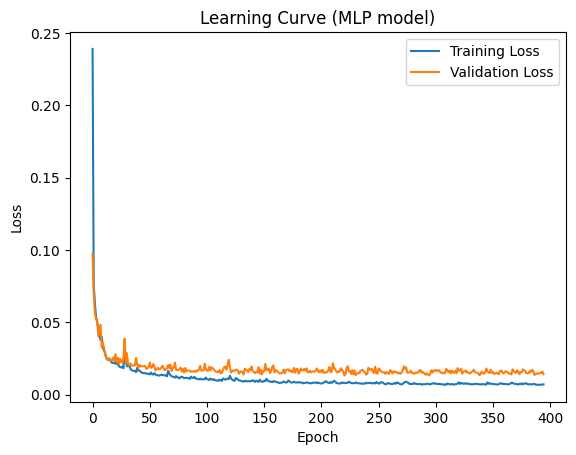

In [22]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Learning Curve (MLP model)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.savefig('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/plots/MLP_model_learning_curve.svg', bbox_inches = 'tight')
plt.show()

In [23]:
train_loss = history.history['loss'][-1]
train_mae = history.history['mae'][-1]
print(f"Training Loss: {train_loss:.4f}")
print(f"Training MAE: {train_mae:.4f}")

Training Loss: 0.0072
Training MAE: 0.0600


In [24]:
val_loss = history.history['val_loss'][-1]
val_mae = history.history['val_mae'][-1]
print(f"Validation Loss: {val_loss:.4f}")
print(f"Validation MAE: {val_mae:.4f}")

Validation Loss: 0.0142
Validation MAE: 0.0848


In [25]:
loss, mae = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss: {loss:.4f}")
print(f"Test MAE: {mae:.4f}")

Test Loss: 0.0147
Test MAE: 0.0863


In [26]:
predictions = model.predict(X_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 334ms/step


In [27]:
predictions.shape

(44, 218)

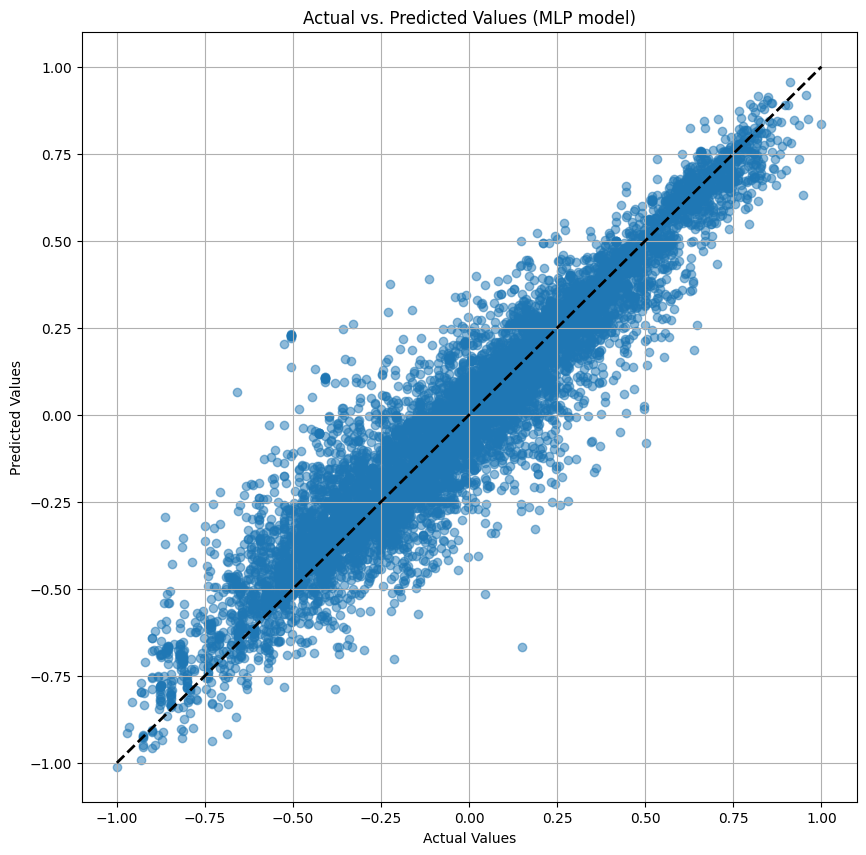

In [28]:
plt.figure(figsize=(10, 10))
plt.scatter(y_test, predictions, alpha=0.5)
plt.plot([y_test.min().min(), y_test.max().max()], [y_test.min().min(), y_test.max().max()], 'k--', lw=2, label='Ideal')
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs. Predicted Values (MLP model)")
plt.grid(True)
plt.savefig('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/plots/MLP_model_actual_vs_pred.svg', bbox_inches = 'tight')
plt.show()

In [29]:
from sklearn.metrics import mean_squared_error

def get_metrics(y_predicted):

  mse = mean_squared_error(y_test, y_predicted)
  print("MSE:", mse)

  from sklearn.metrics import mean_absolute_error
  mae = mean_absolute_error(y_test, y_predicted)
  print("MAE:", mae)

  from sklearn.metrics import median_absolute_error
  medae = median_absolute_error(y_test, y_predicted,)
  print("MedAE:", medae)

  def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

  mape = mean_absolute_percentage_error(y_test, y_predicted)
  print('Mean absolute percentage error:', mape)

In [30]:
get_metrics(y_predicted = predictions)

MSE: 0.014726046472787857
MAE: 0.08630251884460449
MedAE: 0.065825306
Mean absolute percentage error: 127.91174


/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


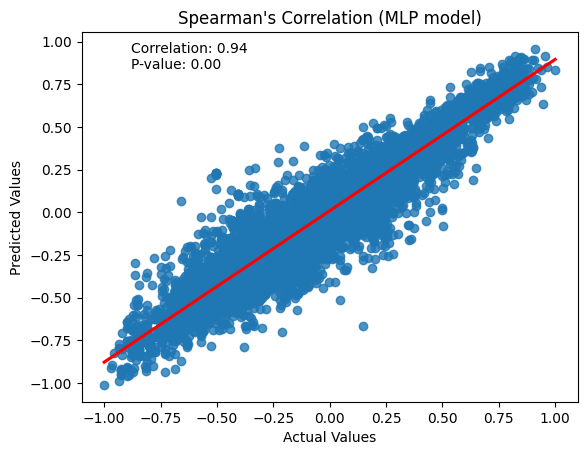

In [31]:
from scipy.stats import spearmanr

def get_spearman_correlation(model_predictions):

  correlation, p_value = spearmanr(X_test, model_predictions)

  correlation_df = pd.DataFrame({'Actual': y_test.flatten(), 'Predicted': model_predictions.flatten()})

  # Calculate Spearman's correlation
  correlation, p_value = spearmanr(correlation_df['Actual'], correlation_df['Predicted'])

  # Add correlation and p-value to DataFrame
  correlation_df['Correlation'] = correlation
  correlation_df['P-value'] = p_value

  sns.regplot(x='Actual', y='Predicted', data=correlation_df, line_kws={'color': 'red'})
  plt.title(f'Spearman\'s Correlation (MLP model)')
  plt.xlabel('Actual Values')
  plt.ylabel('Predicted Values')

  # Add correlation and p-value as text
  plt.text(0.1, 0.9, f'Correlation: {correlation:.2f}\nP-value: {p_value:.2f}', transform=plt.gca().transAxes)
  plt.savefig('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/plots/MLP_model_spearmans_reg_plot.svg', bbox_inches = 'tight')
  plt.show()


get_spearman_correlation(predictions)

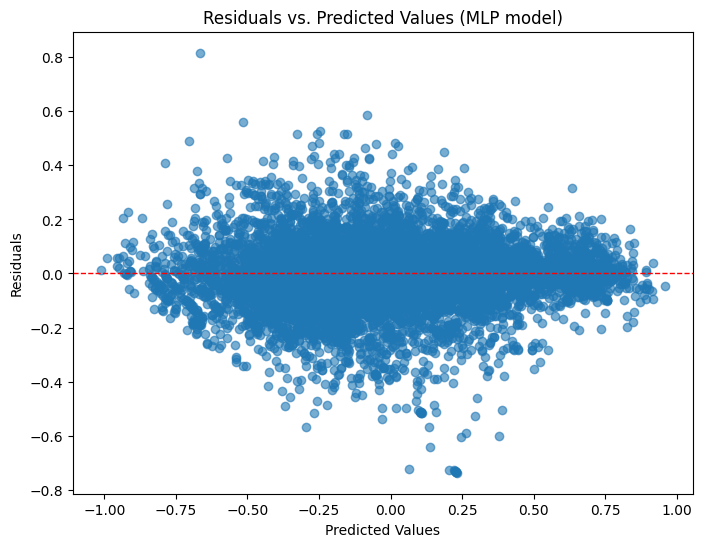

In [32]:
#Checking for heteroscedasticity
!pip install statsmodels

import statsmodels.api as sm

def get_residuals_vs_pred_plot(model_predictions):

  residuals = (y_test - model_predictions).ravel()

  plt.figure(figsize=(8, 6))
  plt.scatter(model_predictions.ravel(), residuals, alpha=0.6)
  plt.axhline(y=0, color='red', linestyle='--', linewidth=1)
  plt.title(f"Residuals vs. Predicted Values (MLP model)")
  plt.xlabel("Predicted Values")
  plt.ylabel("Residuals")
  plt.savefig('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/plots/MLP_model_residuals.svg', bbox_inches = 'tight')
  plt.show()

get_residuals_vs_pred_plot(predictions)

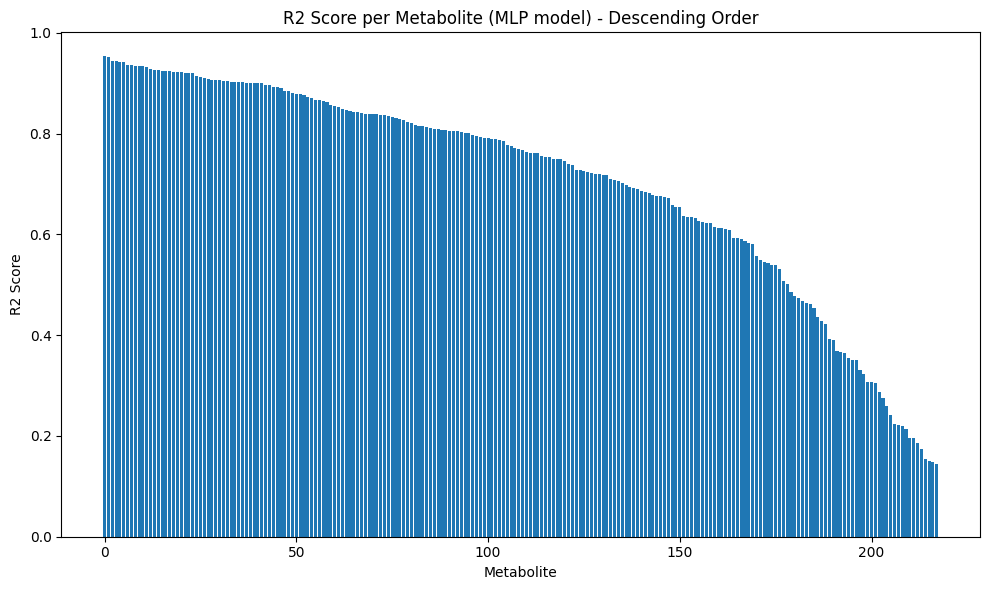

In [33]:
from sklearn.metrics import r2_score

def plot_r2_per_metabolite(y_true, y_pred, metabolite_names):
    """Plots the R2 score per metabolite for a given model in descending order."""

    r2_scores = []  # Initialize list to store R2 scores
    for i in range(y_true.shape[1]):  # Iterate through each metabolite (column)
        # Calculate R2 for the current metabolite across all samples
        r2 = r2_score(y_true[:, i], y_pred[:, i])
        r2_scores.append(r2)  # Add the R2 score to the list

    # Create a DataFrame for sorting
    r2_df = pd.DataFrame({'Metabolite': metabolite_names, 'R2 Score': r2_scores})

    # Sort the DataFrame by R2 scores in descending order
    r2_df = r2_df.sort_values(by=['R2 Score'], ascending=False)
    r2_df.to_csv('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/results/r2_df_MLP.csv', index =True)

    # Plotting
    plt.figure(figsize=(10, 6))  # Adjust figure size as needed
    plt.bar(range(len(r2_df)), r2_df['R2 Score'])  # Create bar plot of R2 scores
    plt.xticks()  # Set x-axis labels to metabolite names
    plt.xlabel("Metabolite")
    plt.ylabel("R2 Score")
    plt.title(f"R2 Score per Metabolite (MLP model) - Descending Order")
    plt.tight_layout()  # Adjust layout to prevent labels from overlapping
    plt.savefig('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/plots/MLP_model_r2_per_metabolite.svg', bbox_inches = 'tight')
    plt.show()

# Get the original metabolite names before splitting and normalization
original_metabolite_names = metabolites.columns

# Call the function with y_test, predictions, and original_metabolite_names
plot_r2_per_metabolite(y_test, predictions, original_metabolite_names)

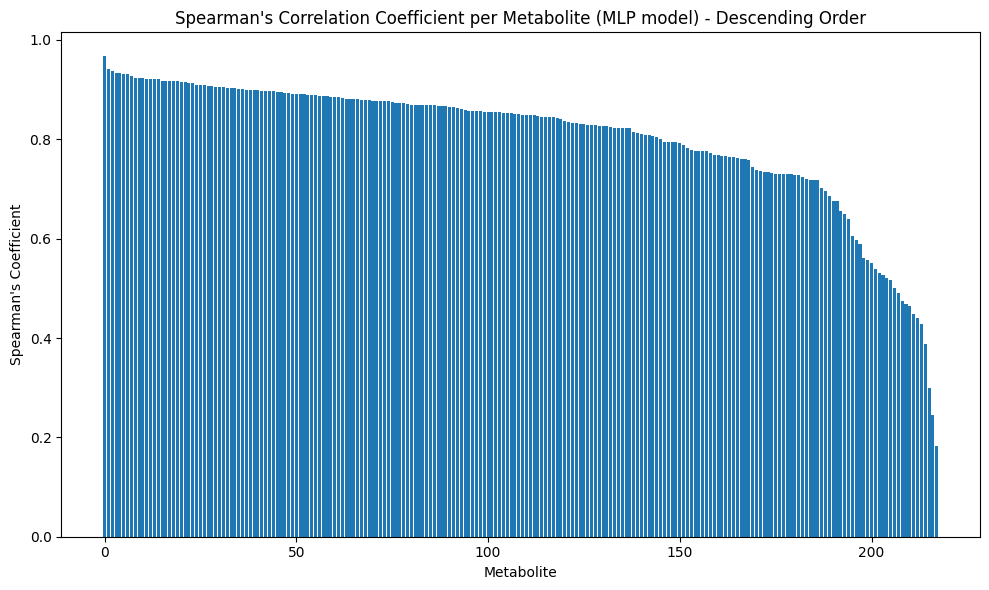

In [34]:
def plot_spearman_per_metabolite(y_true, y_pred, metabolite_names):
    """Plots the Spearman's correlation coefficient per metabolite for a given model."""

    spearman_coeffs = []  # Initialize list to store Spearman's coefficients
    for i in range(y_true.shape[1]):  # Iterate through each metabolite (column)
        # Ensure y_true and y_pred for the current metabolite are 1D arrays
        coeff, _ = spearmanr(y_true[:, i].ravel(), y_pred[:, i].ravel())  # Calculate Spearman's coefficient
        spearman_coeffs.append(coeff)  # Add the coefficient to the list

    # Create a DataFrame for sorting using metabolite names
    spearman_df = pd.DataFrame({'Metabolite': metabolite_names, 'Spearman Coefficient': spearman_coeffs})

    # Sort the DataFrame by Spearman's coefficients in descending order
    spearman_df = spearman_df.sort_values(by=['Spearman Coefficient'], ascending=False)
    spearman_df.to_csv('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/results/spearman_df_MLP.csv', index =True)

    # Plotting
    plt.figure(figsize=(10, 6))  # Adjust figure size as needed
    # Use the metabolite names from the sorted DataFrame for x-axis labels
    plt.bar(range(len(spearman_df)), spearman_df['Spearman Coefficient'])  # Create bar plot of coefficients
    plt.xticks()  # Set x-axis labels to metabolite names and rotate them
    plt.xlabel("Metabolite")
    plt.ylabel("Spearman's Coefficient")
    plt.title(f"Spearman's Correlation Coefficient per Metabolite (MLP model) - Descending Order")
    plt.tight_layout()  # Adjust layout to prevent labels from overlapping
    plt.savefig('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/plots/MLP_model_spearmans_per_metabolite.svg', bbox_inches = 'tight')
    plt.show()

original_metabolite_names = metabolites.columns

# Call the function with y_test, predictions, and original_metabolite_names
plot_spearman_per_metabolite(y_test, predictions, original_metabolite_names)